In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [27]:
# Download the dataset
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

--2025-10-19 16:22:28--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv.2’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.05s   

2025-10-19 16:22:28 (1.70 MB/s) - ‘course_lead_scoring.csv.2’ saved [80876/80876]



In [2]:
df = pd.read_csv('course_lead_scoring.csv')
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [3]:
# Check for missing values
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [4]:
cat_cols = list(df.select_dtypes(include=['object']).columns)
num_cols = list(df.select_dtypes(include=['int64', 'float64']).columns)

df[cat_cols] = df[cat_cols].fillna('NA')
df[num_cols] = df[num_cols].fillna(0)

In [5]:
# Check for missing values again
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [6]:
# Train-val-test split
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

len(df_train), len(df_val), len(df_test)

(876, 293, 293)

In [7]:
# Reset index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [8]:
# Remove target from features
y_train = df_train['converted'].values
y_val = df_val['converted'].values
y_test = df_test['converted'].values

del df_train['converted']
del df_val['converted']
del df_test['converted']

num_cols.pop(num_cols.index('converted'))  # Remove target from numerical columns list

'converted'

In [9]:
# Calculate ROC AUC to estimate feature importance of variables
from sklearn.metrics import roc_auc_score

def calculate_feature_importance(feature, y):
    score = roc_auc_score(y, feature)
    return score

feature_importances = {}
for col in df_train[num_cols].columns:
    feature_importances[col] = calculate_feature_importance(df_train[col].values, y_train)
sorted_features = sorted(feature_importances.items(), key=lambda x: x[1], reverse=True)

sorted_features

[('number_of_courses_viewed', 0.7635680590007088),
 ('interaction_count', 0.738270176293409),
 ('lead_score', 0.6144993577250176),
 ('annual_income', 0.5519578313253012)]

In [10]:
# Prepare datasets
from sklearn.feature_extraction import DictVectorizer
dv = DictVectorizer(sparse=False)

train_dicts = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

test_dicts = df_test.to_dict(orient='records')
X_test = dv.transform(test_dicts)

In [11]:
# Train model
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
# Calculate ROC AUC on validation set
y_val_pred = model.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_val_pred)
roc_auc

0.8171316268814112

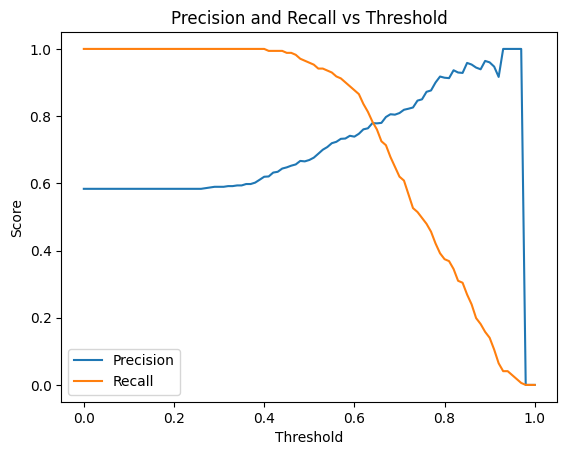

In [13]:
# Plot precision-recall curve manually
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.0, 1.01, 0.01)
precisions = []
recalls = []
for t in thresholds:
    y_val_pred_t = (y_val_pred >= t).astype(int)
    precisions.append(precision_score(y_val, y_val_pred_t, zero_division=0))
    recalls.append(recall_score(y_val, y_val_pred_t, zero_division=0))

# Plot precision and recall compared to threshold
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()

In [14]:
# Calculate F1 score
from sklearn.metrics import f1_score

best_f1 = 0
best_threshold = 0
for t in thresholds:
    y_val_pred_t = (y_val_pred >= t).astype(int)
    f1 = f1_score(y_val, y_val_pred_t, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

best_f1, best_threshold


(0.8125, np.float64(0.5700000000000001))

In [18]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[cat_cols + num_cols].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter=1000, solver='liblinear')
    model.fit(X_train, y_train)
    
    return dv, model


def predict(df, dv, model):
    dicts = df[cat_cols + num_cols].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [19]:
# Cross validation
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=1)

scores = []

for train_index, val_index in kf.split(df_full_train):
    df_train_cv = df_full_train.iloc[train_index]
    df_val_cv = df_full_train.iloc[val_index]
    
    y_train_cv = df_train_cv['converted'].values
    y_val_cv = df_val_cv['converted'].values
    
    del df_train_cv['converted']
    del df_val_cv['converted']
    
    dv, model = train(df_train_cv, y_train_cv, C=1.0)
    y_val_pred = predict(df_val_cv, dv, model)
    
    roc_auc = roc_auc_score(y_val_cv, y_val_pred)
    scores.append(roc_auc)

np.mean(scores), np.std(scores)


(np.float64(0.8221089148573075), np.float64(0.03580711942905165))

In [20]:
for C in [0.000001, 0.001, 1]:
    scores = []

    for train_index, val_index in kf.split(df_full_train):
        df_train_cv = df_full_train.iloc[train_index]
        df_val_cv = df_full_train.iloc[val_index]
        
        y_train_cv = df_train_cv['converted'].values
        y_val_cv = df_val_cv['converted'].values
        
        del df_train_cv['converted']
        del df_val_cv['converted']
        
        dv, model = train(df_train_cv, y_train_cv, C=C)
        y_val_pred = predict(df_val_cv, dv, model)
        
        roc_auc = roc_auc_score(y_val_cv, y_val_pred)
        scores.append(roc_auc)

    print(f'C={C}: Mean ROC AUC={np.mean(scores):.3f}, Std={np.std(scores):.3f}')

C=1e-06: Mean ROC AUC=0.560, Std=0.024
C=0.001: Mean ROC AUC=0.867, Std=0.029
C=1: Mean ROC AUC=0.822, Std=0.036
